In [1]:
import torch
import numpy as np
import pandas as pd

from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

d:\Anaconda3\envs\NLP\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
dataset = load_dataset("go_emotions")

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

In [4]:
dataset["train"][0]

{'text': "My favourite food is anything I didn't have to cook myself.",
 'labels': [27],
 'id': 'eebbqej'}

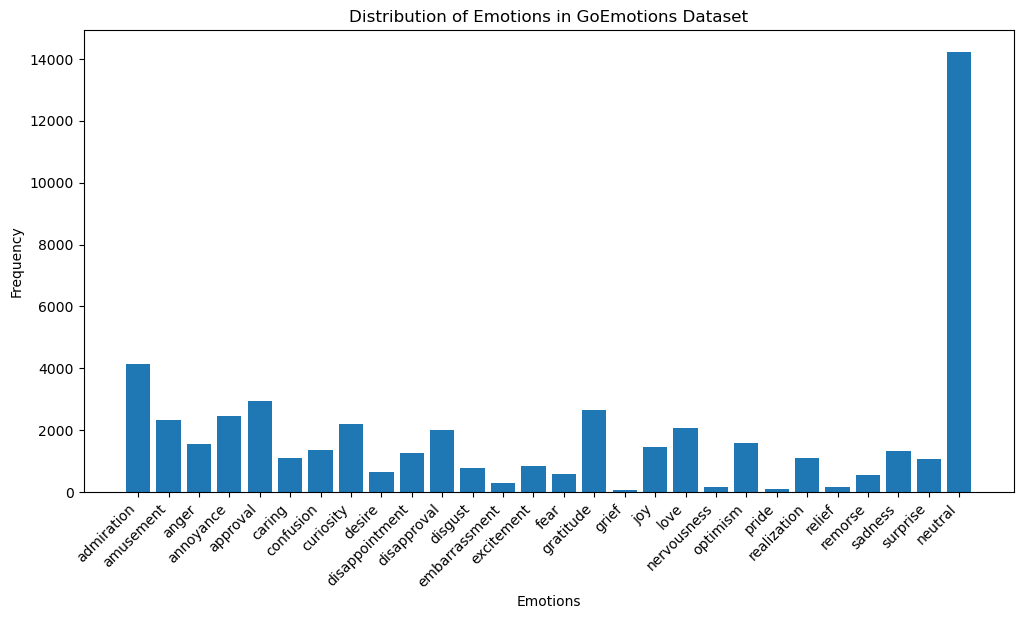

In [7]:
import matplotlib.pyplot as plt
from collections import Counter

# if using original multi-label go_emotions
emotion_names = dataset['train'].features['labels'].feature.names

all_labels = [label for labels_list in dataset['train']['labels'] for label in labels_list]
label_counts = Counter(all_labels)

plt.figure(figsize=(12, 6))
plt.bar(emotion_names, [label_counts.get(i, 0) for i in range(len(emotion_names))])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Emotions')
plt.ylabel('Frequency')
plt.title('Distribution of Emotions in GoEmotions Dataset')
plt.show()

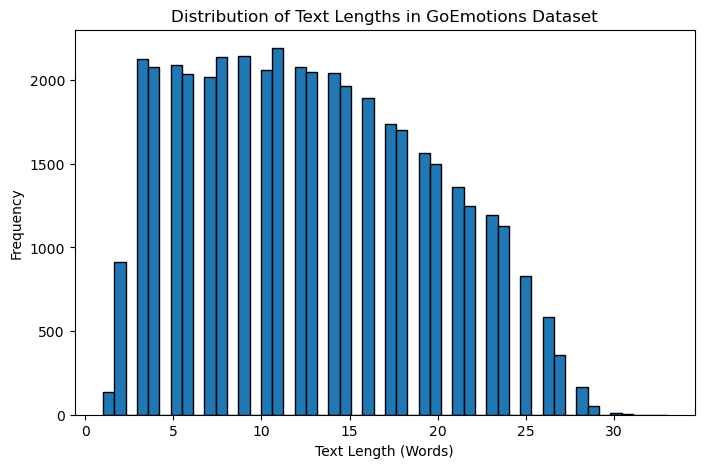

In [9]:
# Calculate text lengths (in words)
text_lengths = [len(text.split()) for text in dataset['train']['text']]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(text_lengths, bins=50, edgecolor='black')
plt.xlabel('Text Length (Words)')
plt.ylabel('Frequency')
plt.title('Distribution of Text Lengths in GoEmotions Dataset')
plt.show()

In [6]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [7]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

In [8]:
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [9]:
def convert_to_single_label(example):
    if len(example["labels"]) > 0:
        example["label"] = example["labels"][0]
    else:
        example["label"] = 0
    return example

dataset = dataset.map(convert_to_single_label)

In [10]:
dataset = dataset.remove_columns(["labels"])
dataset = dataset.rename_column("label", "labels")

In [11]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

In [12]:
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [13]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=28
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12715.24it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider t

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted"
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [16]:
training_args = TrainingArguments(
    output_dir="../models/goemotions_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [19]:
trainer.train()
trainer.save_model("../models/goemotions_bert")
tokenizer.save_pretrained("../models/goemotions_bert")

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.474899,1.414016,0.578695,0.557932,0.566846,0.578695
2,1.207546,1.366635,0.585146,0.575753,0.574217,0.585146
3,0.973489,1.392702,0.590675,0.580342,0.578111,0.590675


d:\Anaconda3\envs\NLP\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.67it/s]
d:\Anaconda3\envs\NLP\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.17it/s]
d:\Anaconda3\envs\NLP\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

('../models/goemotions_bert\\tokenizer_config.json',
 '../models/goemotions_bert\\tokenizer.json')